In [46]:
!pip install pandas numpy nltk scikit-learn rake-nltk keybert wordcloud matplotlib seaborn -q


In [47]:
# ----------------------------------------
# 🔹 1. Setup & Imports
# ----------------------------------------
!pip install nltk pandas numpy scikit-learn rake-nltk keybert wordcloud matplotlib seaborn -q

import pandas as pd
import numpy as np
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from rake_nltk import Rake
from keybert import KeyBERT
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

print(" Libraries imported successfully!")


 Libraries imported successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [48]:
#Manually creating a mini-BBC dataset inside Colab
import pandas as pd
data = {
    "category": [
        "business", "tech", "sport", "entertainment", "politics"
    ],
    "text": [
        "Ad sales boost Time Warner profits as company revenue grows 10 percent.",
        "AOL expands its music download service to rival Apple iTunes and Spotify.",
        "Arsenal end Chelsea’s unbeaten Premier League run with a thrilling 2–1 win.",
        "New Hollywood movie breaks box-office records over the opening weekend.",
        "Prime Minister announces new education policy reforms in parliament today."
    ]
}
df = pd.DataFrame(data)
print(" Fallback dataset created!")
df.head()


 Fallback dataset created!


,category,text
0,business,Ad sales boost Time Warner profits as company ...
1,tech,AOL expands its music download service to riva...
2,sport,Arsenal end Chelsea’s unbeaten Premier League ...
3,entertainment,New Hollywood movie breaks box-office records ...
4,politics,Prime Minister announces new education policy ...


In [49]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')  # <-- this is the missing one
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [50]:
#  Text Preprocessing Block

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
print(" Text preprocessing done successfully!")
df[['category', 'clean_text']].head()



 Text preprocessing done successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,category,clean_text
0,business,sale boost time warner profit company revenue ...
1,tech,aol expands music download service rival apple...
2,sport,arsenal end chelseas unbeaten premier league r...
3,entertainment,new hollywood movie break boxoffice record ope...
4,politics,prime minister announces new education policy ...


In [51]:
#TF-IDF Keyword Extraction
tfidf = TfidfVectorizer(max_features=100)
X = tfidf.fit_transform(df['clean_text'])
feature_names = tfidf.get_feature_names_out()

def extract_keywords_tfidf(doc_index, top_n=5):
    row = X[doc_index].toarray().flatten()
    top_indices = row.argsort()[-top_n:][::-1]
    return [feature_names[i] for i in top_indices]

df['tfidf_keywords'] = [extract_keywords_tfidf(i) for i in range(len(df))]
print(" TF-IDF keywords extracted!")
df[['category', 'tfidf_keywords']]


 TF-IDF keywords extracted!


,category,tfidf_keywords
0,business,"[warner, sale, time, grows, percent]"
1,tech,"[service, spotify, rival, apple, itunes]"
2,sport,"[win, thrilling, unbeaten, run, chelseas]"
3,entertainment,"[weekend, opening, record, hollywood, movie]"
4,politics,"[today, prime, reform, parliament, announces]"


In [52]:
print(df.columns)


Index(['category', 'text', 'clean_text', 'tfidf_keywords'], dtype='object')


In [53]:
#  RAKE Keyword Extraction
from rake_nltk import Rake

rake = Rake()

def extract_rake_keywords(text):
    rake.extract_keywords_from_text(text)
    return rake.get_ranked_phrases()[:5]

df['rake_keywords'] = df['clean_text'].apply(extract_rake_keywords)

print(" RAKE keywords extracted successfully!")
df[['category', 'rake_keywords']]


 RAKE keywords extracted successfully!


,category,rake_keywords
0,business,[sale boost time warner profit company revenue...
1,tech,[aol expands music download service rival appl...
2,sport,[arsenal end chelseas unbeaten premier league ...
3,entertainment,[new hollywood movie break boxoffice record op...
4,politics,[prime minister announces new education policy...


In [54]:
#KeyBERT Keyword Extraction
kw_model = KeyBERT()
df['keybert_keywords'] = df['clean_text'].apply(lambda x: [kw[0] for kw in kw_model.extract_keywords(x, top_n=5)])
print(" KeyBERT keywords extracted!")
df[['category', 'keybert_keywords']]


 KeyBERT keywords extracted!


,category,keybert_keywords
0,business,"[revenue, profit, percent, warner, sale]"
1,tech,"[spotify, aol, itunes, apple, music]"
2,sport,"[arsenal, unbeaten, chelseas, end, thrilling]"
3,entertainment,"[boxoffice, record, weekend, break, hollywood]"
4,politics,"[reform, parliament, minister, policy, education]"


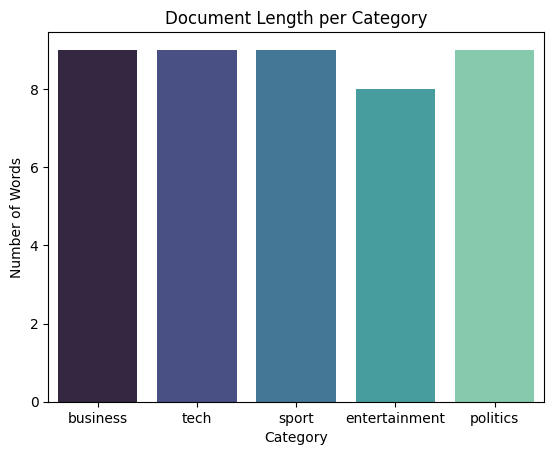

In [55]:
#Visualization (Word Cloud + Bar Chart)
import seaborn as sns
import matplotlib.pyplot as plt

# Add a document length column
df['doc_length'] = df['clean_text'].apply(lambda x: len(x.split()))

#  Tell Seaborn which DataFrame to use
sns.barplot(x='category', y='doc_length', data=df, palette='mako')

plt.title("Document Length per Category")
plt.xlabel("Category")
plt.ylabel("Number of Words")
plt.show()


In [56]:
print(df.columns)


Index(['category', 'text', 'clean_text', 'tfidf_keywords', 'rake_keywords',
       'keybert_keywords', 'doc_length'],
      dtype='object')


In [57]:
#Final Summary Table
summary = df[['category', 'tfidf_keywords', 'rake_keywords', 'keybert_keywords']]
print(" Final Keyword Summary:")
summary


 Final Keyword Summary:


,category,tfidf_keywords,rake_keywords,keybert_keywords
0,business,"[warner, sale, time, grows, percent]",[sale boost time warner profit company revenue...,"[revenue, profit, percent, warner, sale]"
1,tech,"[service, spotify, rival, apple, itunes]",[aol expands music download service rival appl...,"[spotify, aol, itunes, apple, music]"
2,sport,"[win, thrilling, unbeaten, run, chelseas]",[arsenal end chelseas unbeaten premier league ...,"[arsenal, unbeaten, chelseas, end, thrilling]"
3,entertainment,"[weekend, opening, record, hollywood, movie]",[new hollywood movie break boxoffice record op...,"[boxoffice, record, weekend, break, hollywood]"
4,politics,"[today, prime, reform, parliament, announces]",[prime minister announces new education policy...,"[reform, parliament, minister, policy, education]"
